# **Applied Machine Learning Lab-(MCSE630P)**

**Assignment 2-Logistic Regression**

**Name:** Shrihariharan S [24MCS1058]

[link text](https://)Logistic Regression:


*  Taken the Logistic regression model from Kaggle https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression
*  Done some pre-processing, Used heatMap to find the co-relation
*  Used IQR technique for capping the outliers
* Handled Missing values using imputation method by using Mean Values
* Trained the model using the parameters that are have more co-relation with TenYearCHD
* Trained the model using Logistic Regression using training set
* Predicted the outcome using test set
* Plotted confusion matrix for performance evaluation
* Calculated various performance metric values like Accuracy, precision,Recall, F1 score



In [ ]:
! pip install -q kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"shrihariharanshankar","key":"837f3e44a5a2f4e1f9afeba5d0ddaa2b"}'}

In [ ]:
! mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
! cp kaggle.json ~/.kaggle/

In [ ]:
! chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Downloading the dataset from Kaggle
! kaggle datasets download -d dileep070/heart-disease-prediction-using-logistic-regression

Dataset URL: https://www.kaggle.com/datasets/dileep070/heart-disease-prediction-using-logistic-regression
License(s): unknown
heart-disease-prediction-using-logistic-regression.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#unzipping the downloaded file
import zipfile
f=zipfile.ZipFile('/content/heart-disease-prediction-using-logistic-regression.zip','r')
f.extractall('/content')
f.close()

In [ ]:
#exporting Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from pandas.core.common import random_state

In [ ]:
#reading the csv file and storing it in the dataframe hd
hd=pd.DataFrame(pd.read_csv("/content/framingham.csv"))

In [ ]:
hd.head() # first 5 values of dataset

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
hd['TenYearCHD'].value_counts()

,count
TenYearCHD,
0,3594
1,644


In [ ]:
hd.describe() # describes the mean,median,min,max of the dataset


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [ ]:
hd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [ ]:
hd.shape #no.of rows and columns

(4238, 16)

In [ ]:
hd.isnull().sum() #checkinhg for null values

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
hd.drop('education',axis=1) #dropping the column education

,male,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [ ]:
hd

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


<ipython-input-221-4056ed140a94>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_TenYearCHD.index, y=correlation_with_TenYearCHD.values, palette='coolwarm')


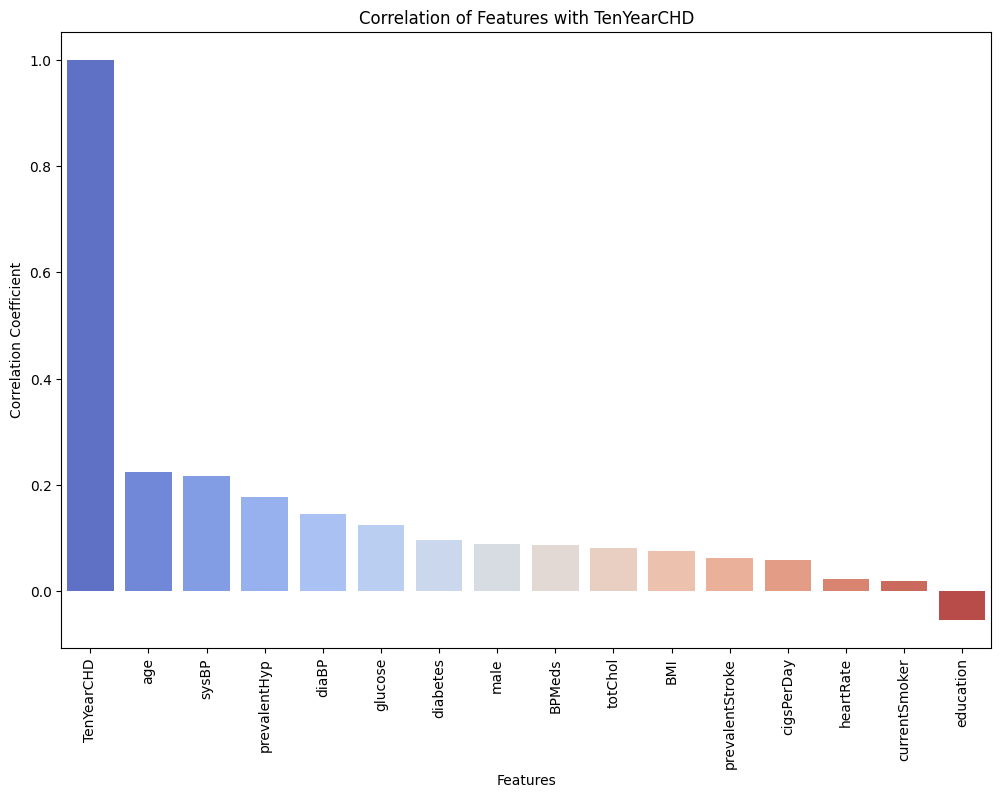

In [ ]:
# using correlation plots like barplot and HeatMAP to find which parameters has highest co-relation with TenYearCHD
correlation_matrix = hd.corr()

correlation_with_TenYearCHD = correlation_matrix['TenYearCHD'].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=correlation_with_TenYearCHD.index, y=correlation_with_TenYearCHD.values, palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Correlation of Features with TenYearCHD')
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.show()

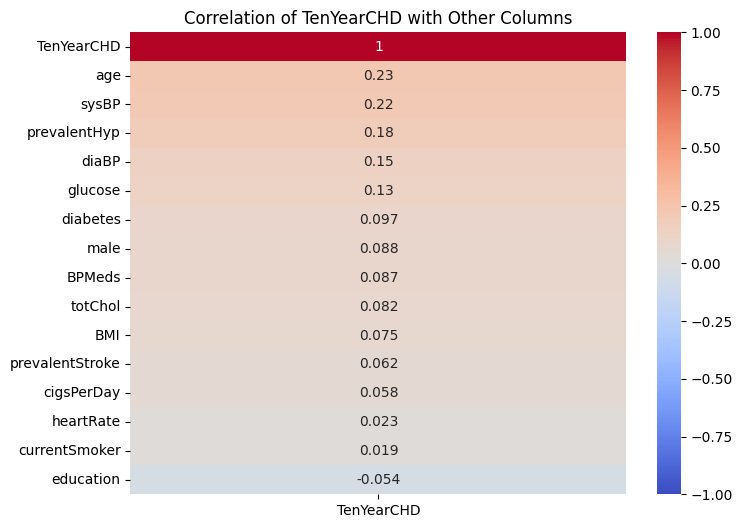

In [ ]:
# using correlation plots like barplot and HeatMAP to find which parameters has highest co-relation with TenYearCHD
corr_matrix = hd.corr()

# Extract the correlation of 'TenYearCHD' with other columns
ten_year_chd_corr = corr_matrix[['TenYearCHD']].sort_values(by='TenYearCHD', ascending=False)

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ten_year_chd_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of TenYearCHD with Other Columns')
plt.show()


<ipython-input-223-8638e4bb6fb3>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(hd['age'])


<Axes: xlabel='age', ylabel='Density'>

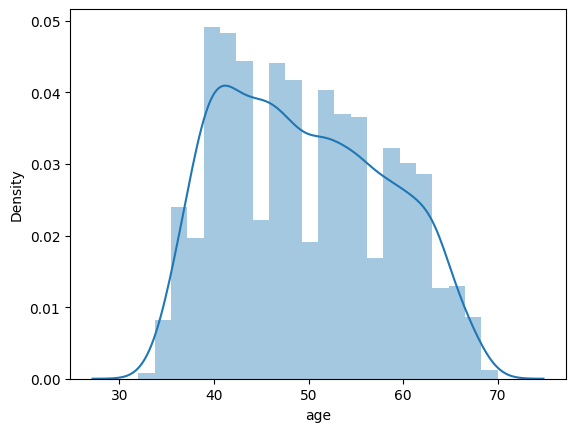

In [ ]:
sns.distplot(hd['age']) #used for analying distribution of values

<ipython-input-224-d8ff7d40786f>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(hd['sysBP'])


<Axes: xlabel='sysBP', ylabel='Density'>

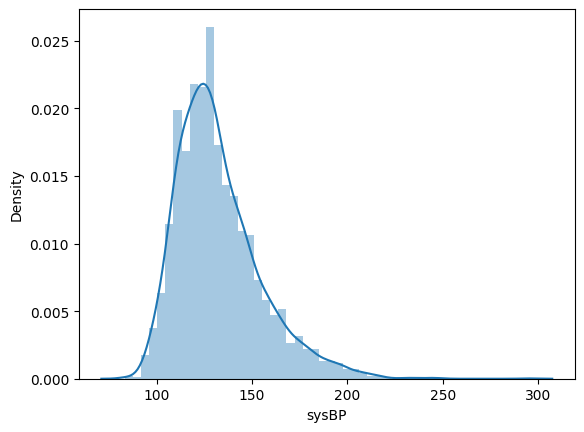

In [ ]:
sns.distplot(hd['sysBP'])

<ipython-input-225-0d69bb92a303>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(hd['diaBP'])


<Axes: xlabel='diaBP', ylabel='Density'>

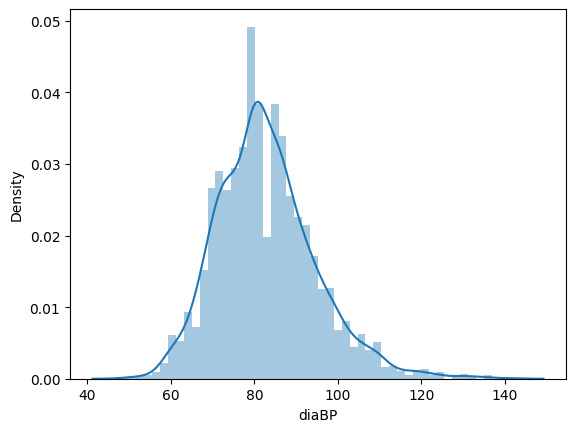

In [ ]:
sns.distplot(hd['diaBP'])

<ipython-input-226-2c8c3b1c88db>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(hd['glucose'])


<Axes: xlabel='glucose', ylabel='Density'>

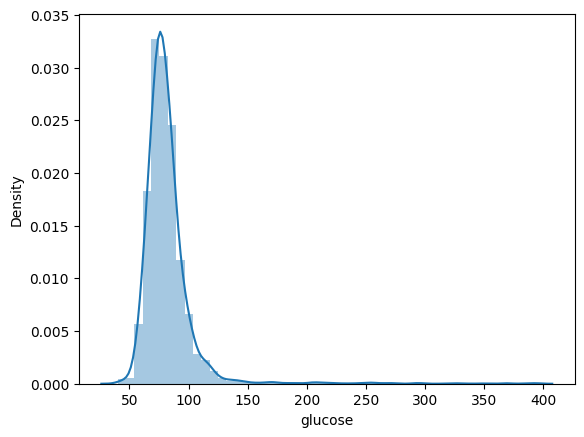

In [ ]:
sns.distplot(hd['glucose'])

<Axes: ylabel='age'>

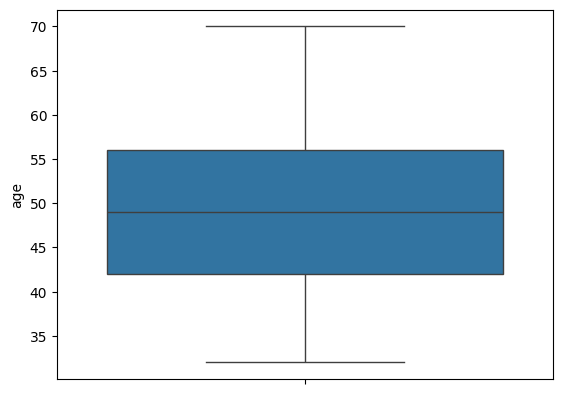

In [ ]:
sns.boxplot(hd['age']) # using boxplot for checking of outliers

<Axes: ylabel='sysBP'>

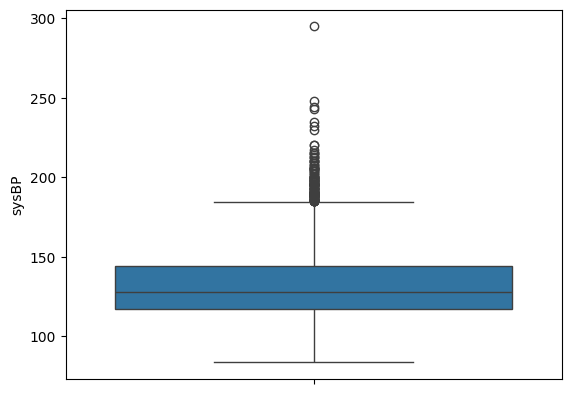

In [ ]:
sns.boxplot(hd['sysBP'])

<Axes: ylabel='diaBP'>

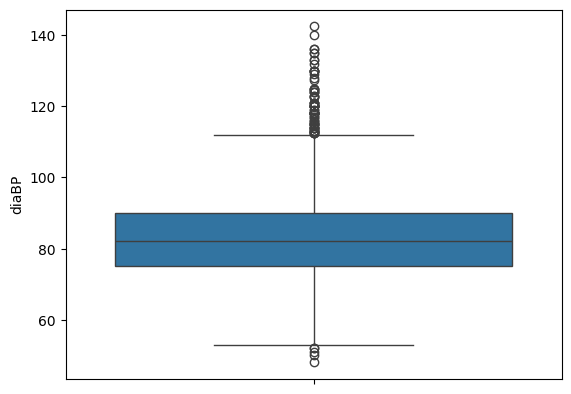

In [ ]:
sns.boxplot(hd['diaBP'])

<Axes: ylabel='glucose'>

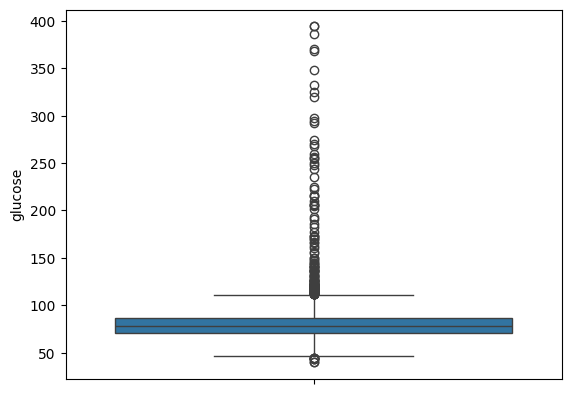

In [ ]:
sns.boxplot(hd['glucose'])

In [ ]:
#capping of outliers using IQR technique for all the columns that are high co relation with TenYearCHD
q1_sysBP =hd['sysBP'].quantile(0.25)
q3_sysBP =hd['sysBP'].quantile(0.75)
iqr_sysBP = q3_sysBP - q1_sysBP

In [ ]:
q1_sysBP, q3_sysBP, iqr_sysBP

(117.0, 144.0, 27.0)

In [ ]:
upper_limit_sysBP = q3_sysBP + 1.5 * iqr_sysBP
lower_limit_sysBP = q1_sysBP - 1.5 * iqr_sysBP

In [ ]:
upper_limit_sysBP, lower_limit_sysBP

(184.5, 76.5)

<Axes: ylabel='sysBP'>

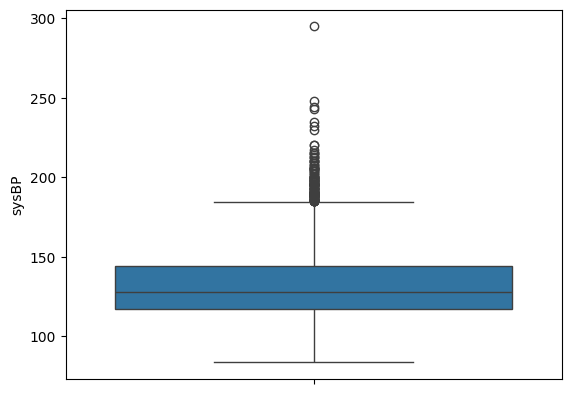

In [ ]:
sns.boxplot(hd['sysBP'])

In [ ]:
hd.loc[ hd['sysBP'] > upper_limit_sysBP, 'sysBP'] = upper_limit_sysBP
hd.loc[ hd['sysBP'] < lower_limit_sysBP, 'sysBP'] = lower_limit_sysBP

<Axes: ylabel='sysBP'>

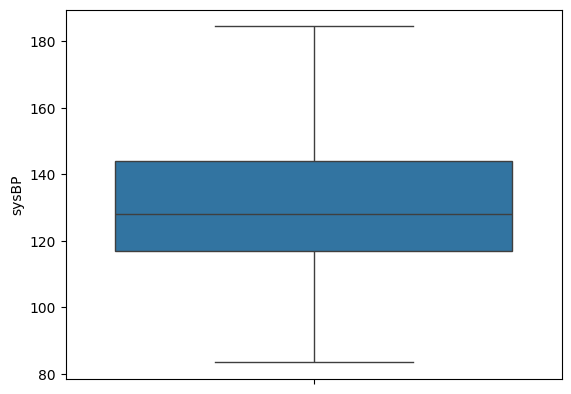

In [ ]:
sns.boxplot(hd['sysBP'])

In [ ]:

q1_diaBP =hd['diaBP'].quantile(0.25)
q3_diaBP =hd['diaBP'].quantile(0.75)
iqr_diaBP = q3_diaBP - q1_diaBP

In [ ]:
q1_diaBP, q3_diaBP, iqr_diaBP

(75.0, 89.875, 14.875)

In [ ]:
upper_limit_diaBP = q3_diaBP + 1.5 * iqr_diaBP
lower_limit_diaBP = q1_diaBP - 1.5 * iqr_diaBP

<Axes: ylabel='diaBP'>

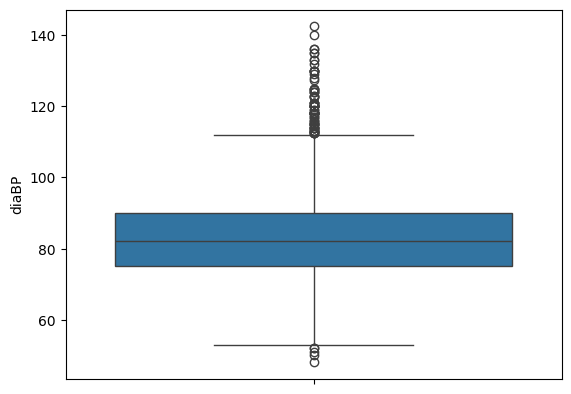

In [ ]:
sns.boxplot(hd['diaBP'])

In [ ]:
hd.loc[ hd['diaBP'] > upper_limit_diaBP, 'diaBP'] = upper_limit_diaBP
hd.loc[ hd['diaBP'] < lower_limit_diaBP, 'diaBP'] = lower_limit_diaBP

<Axes: ylabel='diaBP'>

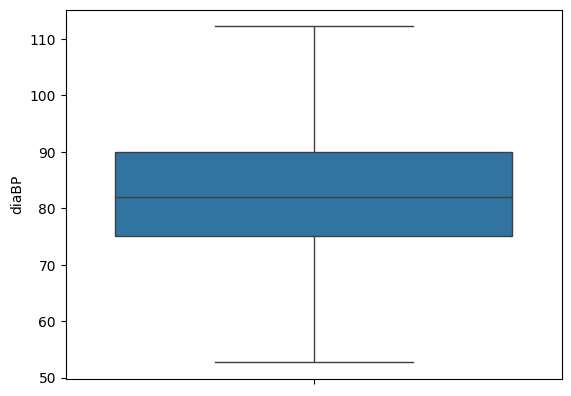

In [ ]:
sns.boxplot(hd['diaBP'])

In [ ]:
'glucose'
q1_glucose =hd['glucose'].quantile(0.25)
q3_glucose =hd['glucose'].quantile(0.75)
iqr_glucose = q3_glucose - q1_glucose


In [ ]:
upper_limit_glucose = q3_glucose + 1.5 * iqr_glucose
lower_limit_glucose = q1_glucose - 1.5 * iqr_glucose

In [ ]:
hd.loc[ hd['glucose'] > upper_limit_glucose, 'glucose'] = upper_limit_glucose
hd.loc[ hd['glucose'] < lower_limit_glucose, 'glucose'] = lower_limit_glucose

<Axes: ylabel='glucose'>

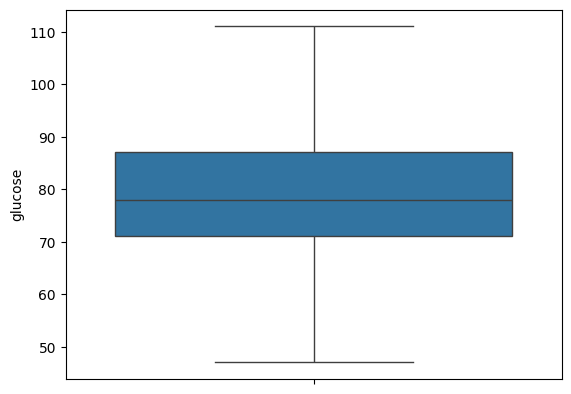

In [ ]:
sns.boxplot(hd['glucose'])

In [ ]:
hd

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


In [ ]:
hd.isnull().sum()

,0
male,0
age,0
education,105
currentSmoker,0
cigsPerDay,29
BPMeds,53
prevalentStroke,0
prevalentHyp,0
diabetes,0
totChol,50


In [ ]:
# Taking the columns that are high corelation with TenYearCHD in X
X={'male':hd['male'],'age':hd['age'],'sysBP':hd['sysBP'],'diaBP':hd['diaBP'],'glucose':hd['glucose'], 'prevalentHyp': hd['prevalentHyp'],'diabetes':hd['diabetes'],}


In [ ]:
X=pd.DataFrame(X)

In [ ]:
# Taking TenYearCHD in Y
Y=hd['TenYearCHD']

In [ ]:
Y=pd.DataFrame(Y)

In [ ]:
X.isnull().sum() # checking for missing values

,0
male,0
age,0
sysBP,0
diaBP,0
glucose,388
prevalentHyp,0
diabetes,0


In [ ]:
Y.isnull().sum()

,0
TenYearCHD,0


<Axes: ylabel='sysBP'>

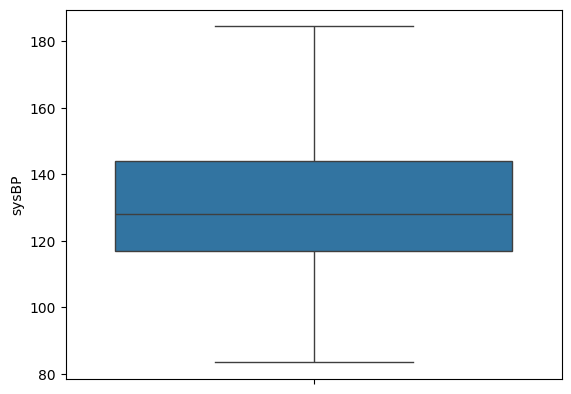

In [ ]:
sns.boxplot(X['sysBP'])


<Axes: ylabel='diaBP'>

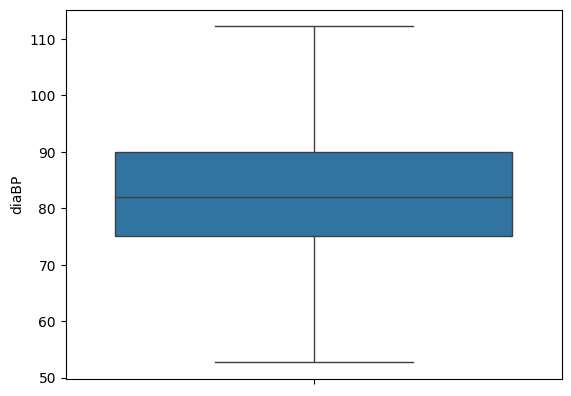

In [ ]:
sns.boxplot(X['diaBP'])

<Axes: ylabel='glucose'>

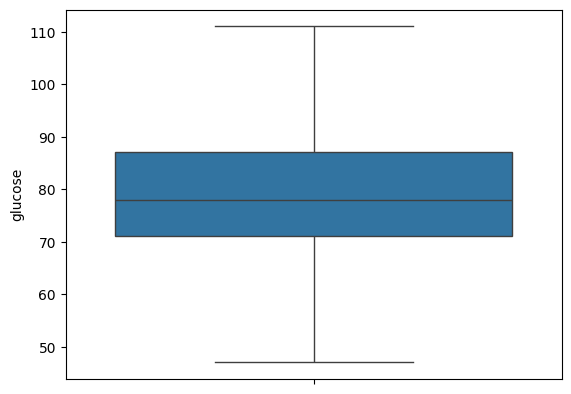

In [ ]:
sns.boxplot(X['glucose'])

In [ ]:
X

,male,age,sysBP,diaBP,glucose,prevalentHyp,diabetes
0,1,39,106.0,70.0,77.0,0,0
1,0,46,121.0,81.0,76.0,0,0
2,1,48,127.5,80.0,70.0,0,0
3,0,61,150.0,95.0,103.0,1,0
4,0,46,130.0,84.0,85.0,0,0
...,...,...,...,...,...,...,...
4233,1,50,179.0,92.0,86.0,1,0
4234,1,51,126.5,80.0,68.0,0,0
4235,0,48,131.0,72.0,86.0,0,0
4236,0,44,126.5,87.0,NaN,0,0


In [ ]:
Y

,TenYearCHD
0,0
1,0
2,0
3,1
4,0
...,...
4233,1
4234,0
4235,0
4236,0


In [ ]:
X.isnull().sum()

,0
male,0
age,0
sysBP,0
diaBP,0
glucose,388
prevalentHyp,0
diabetes,0


In [ ]:
X.describe()

,male,age,sysBP,diaBP,glucose,prevalentHyp,diabetes
count,4238.000000,4238.000000,4238.000000,4238.000000,3850.000000,4238.000000,4238.000000
mean,0.429212,49.584946,131.913285,82.733291,79.927792,0.310524,0.025720
std,0.495022,8.572160,20.647252,11.389783,12.841500,0.462763,0.158316
min,0.000000,32.000000,83.500000,52.687500,47.000000,0.000000,0.000000
25%,0.000000,42.000000,117.000000,75.000000,71.000000,0.000000,0.000000
50%,0.000000,49.000000,128.000000,82.000000,78.000000,0.000000,0.000000
75%,1.000000,56.000000,144.000000,89.875000,87.000000,1.000000,0.000000
max,1.000000,70.000000,184.500000,112.187500,111.000000,1.000000,1.000000


In [ ]:
X=X.fillna(value=X['glucose'].mean()); # inputing missing values of glucose with mean of it

In [ ]:
X.isnull().sum()

,0
male,0
age,0
sysBP,0
diaBP,0
glucose,0
prevalentHyp,0
diabetes,0


In [ ]:
X

,male,age,sysBP,diaBP,glucose,prevalentHyp,diabetes
0,1,39,106.0,70.0,77.000000,0,0
1,0,46,121.0,81.0,76.000000,0,0
2,1,48,127.5,80.0,70.000000,0,0
3,0,61,150.0,95.0,103.000000,1,0
4,0,46,130.0,84.0,85.000000,0,0
...,...,...,...,...,...,...,...
4233,1,50,179.0,92.0,86.000000,1,0
4234,1,51,126.5,80.0,68.000000,0,0
4235,0,48,131.0,72.0,86.000000,0,0
4236,0,44,126.5,87.0,79.927792,0,0


In [ ]:
X=X.values #Taking the values of X and Y

In [ ]:
Y=Y.values

In [ ]:
X

array([[  1.        ,  39.        , 106.        , ...,  77.        ,
          0.        ,   0.        ],
       [  0.        ,  46.        , 121.        , ...,  76.        ,
          0.        ,   0.        ],
       [  1.        ,  48.        , 127.5       , ...,  70.        ,
          0.        ,   0.        ],
       ...,
       [  0.        ,  48.        , 131.        , ...,  86.        ,
          0.        ,   0.        ],
       [  0.        ,  44.        , 126.5       , ...,  79.92779221,
          0.        ,   0.        ],
       [  0.        ,  52.        , 133.5       , ..., 107.        ,
          0.        ,   0.        ]])

In [ ]:
Y

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [ ]:
# used train_test_split function to split training and testing data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=0.3,random_state=1)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2966, 7), (1272, 7), (2966, 1), (1272, 1))

In [ ]:
# Training Logistic model with the training data

In [ ]:
log = LogisticRegression(max_iter=1000, random_state=1)
log.fit(x_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=1000, random_state=1)

In [ ]:
#predicting the y_pred using the test data
y_pred = log.predict(x_test)

In [ ]:
y_pred=pd.DataFrame(y_pred)
y_pred

,0
0,0
1,0
2,0
3,0
4,0
...,...
1267,0
1268,0
1269,0
1270,0


In [ ]:
accuracy_score(y_test, y_pred)  # checking the accuracy of the model

0.8647798742138365

In [ ]:
y_test=pd.DataFrame(y_test)
y_test

,0
0,0
1,0
2,0
3,1
4,0
...,...
1267,0
1268,0
1269,0
1270,0


In [ ]:
y_test.value_counts()

,count
0,
0,1106
1,166


In [ ]:
log.score(x_test,y_test)

0.8647798742138365

In [ ]:
y_pred.value_counts()

,count
0,
0,1254
1,18


In [ ]:
confusion_matrix(y_test, y_pred)

array([[1094,   12],
       [ 160,    6]])

In [ ]:
log.predict_proba(x_test)

array([[0.80214463, 0.19785537],
       [0.94772413, 0.05227587],
       [0.95354825, 0.04645175],
       ...,
       [0.72588973, 0.27411027],
       [0.77664849, 0.22335151],
       [0.86880782, 0.13119218]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.99      0.93      1106
           1       0.33      0.04      0.07       166

    accuracy                           0.86      1272
   macro avg       0.60      0.51      0.50      1272
weighted avg       0.80      0.86      0.81      1272



In [ ]:
#plotting the confusion matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
cm=confusion_matrix(y_test,y_pred)

In [ ]:
cm_display=ConfusionMatrixDisplay(cm)

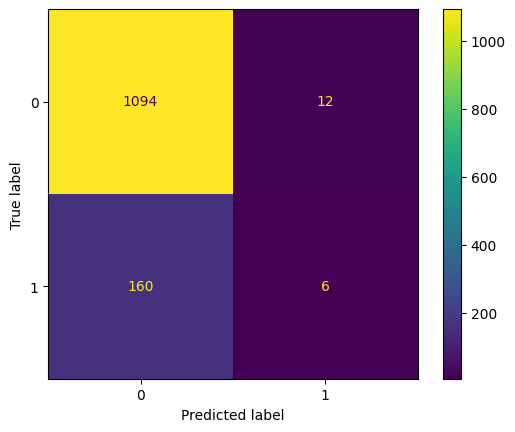

In [ ]:
cm_display.plot() #plotting the confusion matrix

**Summary**

* Preprocessed the data and designed the model using Logistic regression.
From the HeatMap we could see that the co-relation of TenYearCHD is high with age, sysBP, diaBP, glucose,prevalentHyp and Diabetes.

* The model predicts person with the increased values of above parameters will have the higher possibilty of getting heart disease.

* The performance metrics of this model is calculated using classification_report

* Accuracy of the model is also predicted which is nearly 87%

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

NameError: name 'x_train' is not defined